In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from configuration.settings import *
from model.fuelcell import PEMFC_1D
from model.coefficients import *
from model.states import *
from configuration.initialize import *

#### This cell setup the load profile 

In [2]:
delta_i = 0.05e4
delta_t_ini = 0
delta_t_load = 10
delta_t_break = 80
i_max = current_parameters["i_max_pola"]
delta_pola = (delta_t_load, delta_t_break, delta_i, delta_t_ini)
# s. It is the time of one load.
delta_t = delta_t_load + delta_t_break  
# s. The duration of this polarization current.
tf = delta_t_ini + int(i_max / delta_i + 1) * delta_t  
# Load number 
n = int(tf / delta_t) 
# Simulation time interval setup
t0_interval = 0
tf_interval = (delta_t_ini + int(i_max / delta_i + 1) * (delta_t_load + delta_t_break))
time_interval_sim = (t0_interval, tf_interval)

def pola_profile(t):
    # Upward current density for the polarization curve
    i_fc = 0.01e4  # A.m-2. Initialisation of the current density.
    for i in range(n):
        t_switch = delta_t * i  # The current density value changes around this time
        i_fc += delta_i * (1.0 + np.tanh(4 * (t - delta_t_ini - delta_t - t_switch - (delta_t_load / 2))/delta_t_load)) / 2
    return i_fc

#### This is the simulation execution

In [3]:
# Dictionary to store simulation results for each temperature
sim_log = {}

# Locate end of upward ramp and start of downward ramp
tf_up_end = tf_interval
tf_down_start = tf_interval + 50

for idx, Tdes in enumerate([50, 60]):

    statelog = {}
    profile_1d = {"v": [], "O2": [], "H2": [], "saturation": [], "lambda": [], "T": []}
    
    operating_inputs["Tfc"] = Tdes + 273.15 
    operating_inputs["current_density"] = lambda x: 0.5e4
    init_value = init_x(operating_inputs=operating_inputs, parameters=parameters)
    # Current increase
    model = PEMFC_1D(parameters, operating_inputs, init_value)
    sol = solve_ivp(model.dxdt, (0, 90), model.x, method='BDF', max_step=1e-2)
    model._recovery(sol)

    for name in nodes_names_vp:
        profile_1d["v"].append(sol.y[model.solver_variable_names.index(name), -1])
    for name in nodes_name_O2:
        profile_1d["O2"].append(sol.y[model.solver_variable_names.index(name), -1])
    for name in nodes_names_H2:
        profile_1d["H2"].append(sol.y[model.solver_variable_names.index(name), -1])
    for name in nodes_names_s:
        profile_1d["saturation"].append(sol.y[model.solver_variable_names.index(name), -1])
    for name in nodes_lambda:
        profile_1d["lambda"].append(sol.y[model.solver_variable_names.index(name), -1])
    for name in nodes_T:
        profile_1d["T"].append(sol.y[model.solver_variable_names.index(name), -1])


    t_sim = model.variables["t"]
    for key in model.variables.keys():
        statelog[key] = model.variables[key]
    for key in model.elec_variables.keys():
        statelog[key] = model.elec_variables[key]

    # Read corresponding experimental data
    I_sim = np.array(statelog["i_fc"]) * model.parameters["Aact"]
    U_sim = np.array(statelog["Ucell"]) * n_cell

    sim_log[Tdes] = {"t_sim": t_sim, "I_sim": I_sim, "U_sim": U_sim,
                                "model": model, "state_log": statelog}

#### Result visualization : 1D profile

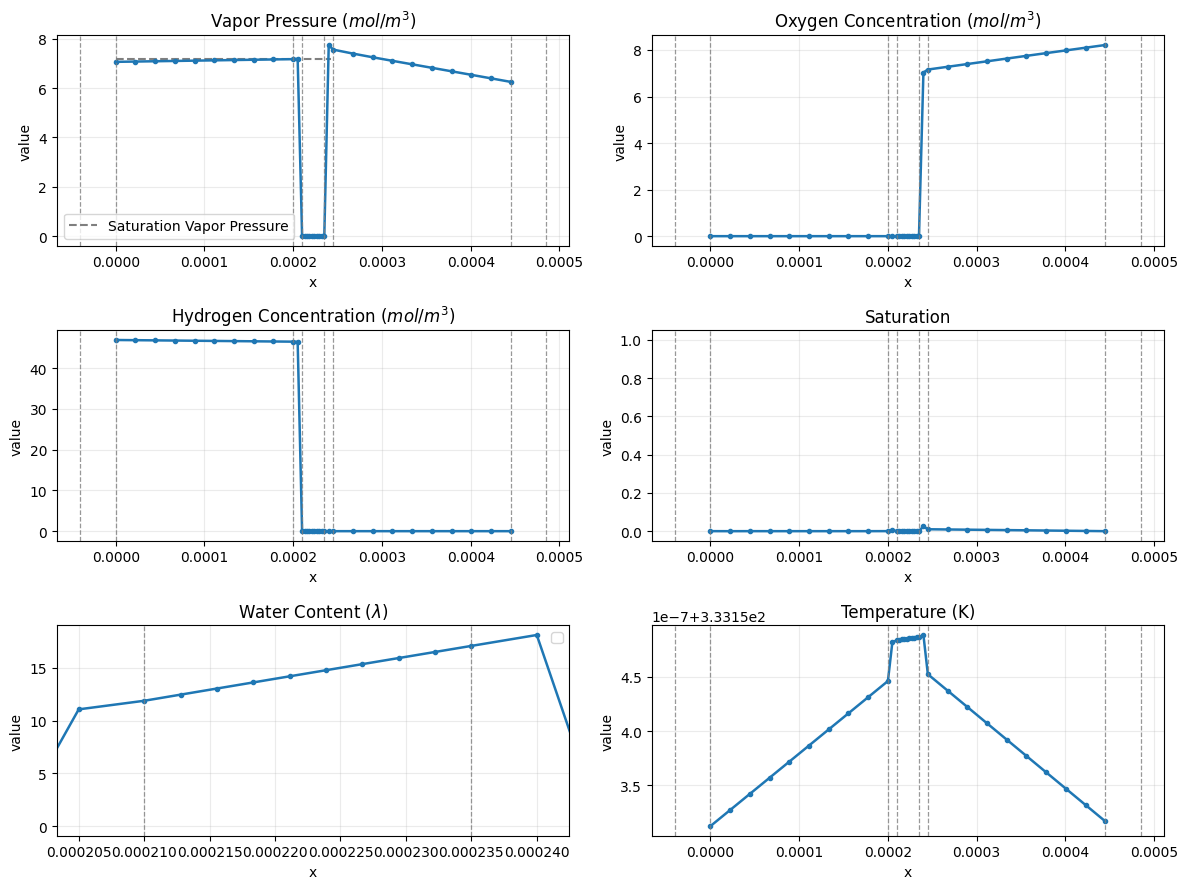

In [4]:
profile_panels = [
    ("v", "Vapor Pressure $(mol/m^3)$"),
    ("O2", "Oxygen Concentration $(mol/m^3)$"),
    ("H2", "Hydrogen Concentration $(mol/m^3)$"),
    ("saturation", "Saturation"),
    ("lambda", "Water Content $(\lambda)$"),
    ("T", "Temperature (K)"),
]

# Profiles are defined on interior material nodes (excluding the 2 external boundary points).
plot_nodes = nodes[1:-1]

n_panels = len(profile_panels)
n_cols = 2
n_rows = (n_panels + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3), sharex=False)
axes_flat = axes.flatten()

for ax, (profile_key, title) in zip(axes_flat, profile_panels):
    if profile_key == "v":
        ax.hlines(C_v_sat(333.15), xmin=0, xmax = Hgdl + Hcl * 3.5 / 2 + Hmem, colors='tab:gray', linestyles='--', label="Saturation Vapor Pressure")
    if profile_key == "saturation":
        ax.set_ylim(-0.05, 1.05)
    if profile_key == "lambda":
        ax.set_xlim(Hgdl + Hcl / 3, Hgdl + Hcl * 3.5 / 2 + Hmem)
    y_values = expand_profile_on_nodes(profile_key, profile_1d[profile_key])
    ax.plot(plot_nodes, y_values, linewidth=1.8, marker="o", markersize=3)
    for x in borders:
        ax.axvline(x=x, color="tab:gray", linestyle="--", linewidth=0.9, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel("value")
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.25)

# Hide any unused axes
for ax in axes_flat[n_panels:]:
    ax.set_visible(False)

axes_flat[0].legend()
axes_flat[4].legend()
plt.tight_layout()
plt.show()
